In [ ]:
!nvidia-smi

Sun Mar 22 00:40:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Small Language Model - 124M Params

In this notebook we replicate GPT2-124M parameter model training
During GPT2 release, open ai released paper, repo and blog post. The original GPT2 model released in the Git repo uses tensorflow. We look for its pytorch version from hugging face.

GPT2 model is a decoder only model. It does not have encoder model or cross attention modules listed in 'Attention is all you need' paper. The transformer in GPT2 Model differs from 'Attention all you need' paper in that has Layer Norm (PreNorm) before the attention layer and linear layer and a final LayerNorm is added before the LMhead layer - the final classifier.

We creat pytorch model with same schema as seen in gpt2 model's state_dict. Initializing weights per gpt2 code for attention layers. Section 2.3 in GP2 paper states that the residual layer weights at initialization are scaled by factor of 1/sqrt(N) where N is the number of residual layers. We use same here.

In addition we add speedups:
- Tensorcore TF32 for GPU
- BF16 (bfloat16) applicable both modern/latest CPU and GPU devices, reducing precision from 32 to 16.
- Torch.compile to compile the neural network. This avoids interpreter greedy execution reducing the number of trips from the memory/cache to chips where execution occurs.
- Flashattention - a fused operation of mathmul->normalization/scaling->masking->softmax->dropout->mathmul. Thought the FLOPS increase the trips backforth from memory to chip is reduced drastically


References:
- Andrej Karapathy: https://www.youtube.com/watch?v=l8pRSuU81PU&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&index=10
- Hugging face transformers for gpt2: https://github.com/huggingface/transformers/tree/main/src/transformers/models/gpt2
- Language Models are Unsupervised Mutlitask Learners-GPT2 paper: https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf
- Language Models are Few Shot Learners-GPT3 paper: https://arxiv.org/abs/2005.14165
- Better language models and their implications-GPT2 Blog https://openai.com/index/better-language-models/
- GPT2 Git repo:https://github.com/openai/gpt-2
- MultiGPU on Kaggle https://medium.com/@speaktoharisudhan/multi-gpu-training-in-kaggle-harnessing-2-t4-for-faster-model-training-tensorflow-f091c22db99e


In [4]:
from transformers import GPT2LMHeadModel, pipeline, set_seed
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import torch
from dataclasses import dataclass
import torch.nn as nn
import math
import tiktoken
import inspect

# Load Hugging Face Pytorch GPT2
1. Original GPT2 model is on tensorflow
2. Review Schema and Weights
3. Generate text from GPT2 hugging face model pipeline

In [ ]:

model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # 124M model gpt2-xl is 1.5B model
sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
    print(k, v.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [ ]:
from transformers import GPT2LMHeadModel
model_gf = GPT2LMHeadModel.from_pretrained("gpt2") # 124M model gpt2-xl is 1.5B model
sd_gf = model_gf.state_dict()

for k, v in sd_gf.items():
    print(k, v.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

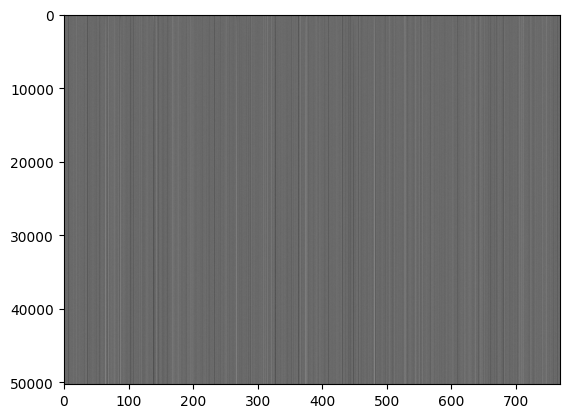

In [ ]:
# In attention is all you need paper the positional embeddings were assigned from sine and cosine functions.
# In GPT2 the position encodings are learned like other parameters. They start random but have learned a regular cyclic like structure

plt.imshow(sd_hf["transformer.wte.weight"], cmap="gray", aspect="auto")

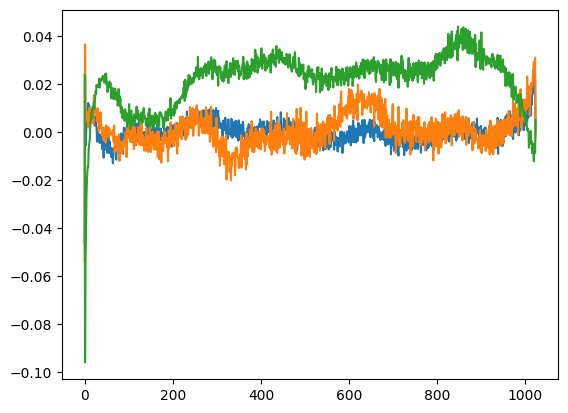

In [ ]:
# plotting positional encoding for some of the channels
# They are initialized at random, have learned a regular cyclic like structure
plt.plot(sd_hf["transformer.wpe.weight"][:, 150])
plt.plot(sd_hf["transformer.wpe.weight"][:, 200])
plt.plot(sd_hf["transformer.wpe.weight"][:, 250])

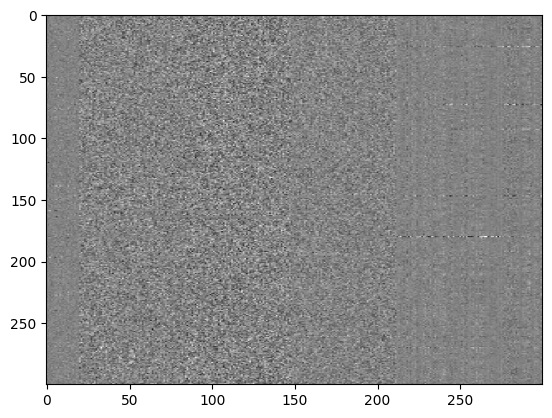

In [ ]:
plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][300:600, 300:600], cmap="gray", aspect="auto")

### Generate Text using pipelines

In [ ]:
# from the GPT2 model - create a pipeline to sample generated text
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello, I'm a language model,", max_length=30, num_return_sequences=5)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Hello, I'm a language model, I'm a language model. In my mind, I'm doing the same thing as you. All these different people are thinking about the same thing.\n\nI'm not talking about what the computer program does. I'm talking about what I'm thinking about. I'm thinking about what my body is thinking about. I'm thinking about what I'm making it. I'm thinking about what I'm making it. What my body is doing. I'm thinking about what my body is thinking about. What's my body doing? What's my body doing? What's my body doing?\n\nLet's talk about this, I'm not a computer programmer. I'm not a software developer. I'm not a computer programmer. I'm not a language model. I'm not a language model. My body is thinking about what I'm doing. What is my body doing? What's my body doing? What's my body doing?\n\nNow, I'm not saying that this is a good thing. But if you want to get better at programming, you can get better at writing. You can get better at being human. You can get

# Create pytorch Model with same schema as GPT2

We will implement the GPT2 model ourselves from scratch and train the model we implement. GPT2 model is a decoder only model. It does not have encoder model or cross attention modules listed in 'Attention is all you need' paper. GPT2.3 Model has Layer Norm (PreNorm) before the attention layer and linear layer and a final LayerNorm is added before the LMhead layer - the final classifier.

Creating model with same schema as seen in gpt2 model's state_dict. Initializing weights per gpt2 paper for attention layer and for Layer pre-norms - they use normal distribution with stddev = 0.02. This std dev is ~ to sqrt(fan_in dimension) considering 768 dim for gpt2 or 1024, 1280, 1600 for other versions in gpt2 bias is initialized to 0. Pytorch has a small stdev for bias by default token embeddings have stddev = 0.02 and position embedding at 0.01

Section 2.3 in GP2 paper states that the residual layer weights at initialization are scaled by factor of 1/sqrt(N) where N is the number of residual layers. This is because variance of distributions C= A + B then varC = varA + varB. Each block joins the residual pathway at MLP and at Attention. So each residual layer weight is scaled down to control the growth at the Nth residual layer the std dev remains ~1.0


In [7]:
# Creating model with same schema as seen in gpt2 model's state_dict


#--------------------------------without flash attention---------------------------

class CausalSelfAttentionNoFlash(nn.Module):
    # Multihead self attention - is a communication / weighted sum / aggregate / pooling layer
    # it is collection info across all tokens in the context - can be seen as a parallel reduce
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query. value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1 # adding custom attribute
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        # Masking the future context. It is not really a 'bias', but following OpenAI/HF naming
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                            .view(1, 1, config.block_size, config.block_size))


    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch
        # nh is "number of heads", hs is "head size", and C (number of channels) = nh * hs
        # In gpt2 (124M) n_head=12, hs=64, nh*hs=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        # attention (materializes the large (T, T) matrix for all the queries and keys)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1))) # token affinity matrix
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf')) # only look at past tokens
        att = nn.functional.softmax(att, dim=-1) # normalizes to sum to 1
        y = att @ v # (B. nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs) # weighted sum of value based on attention
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y) # joining the residual path
        return y


#--------------------------------with flash attention----------------------------
#-----------------------------------------------------------

class CausalSelfAttention(nn.Module):
    # Multihead self attention - is a communication / weighted sum / aggregate / pooling layer
    # it is collection info across all tokens in the context - can be seen as a parallel reduce
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query. value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1 # adding custom attribute
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        # Masking the future context. It is not really a 'bias', but following OpenAI/HF naming
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                            .view(1, 1, config.block_size, config.block_size))


    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch
        # nh is "number of heads", hs is "head size", and C (number of channels) = nh * hs
        # In gpt2 (124M) n_head=12, hs=64, nh*hs=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        # flash attention does not materializes the large (T, T) matrix for all the queries and keys
        y = nn.functional.scaled_dot_product_attention(q, k, v, is_causal=True)
        # att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1))) # token affinity matrix
        # att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf')) # only look at past tokens
        # att = nn.functional.softmax(att, dim=-1) # normalizes to sum to 1
        # y = att @ v # (B. nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs) # weighted sum of value based on attention
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y) # joining the residual path
        return y

class MLP(nn.Module):
    # Feed forward Layer - same weights or operation is applied to all tokens in the context
    # parallel map operation
    # it consists of two linear layers with an activation sandwiched
    # Activation is Gaussian Error Linear Unit, always has local gradient, smooth curve around zero
    # picked by BERT, LMs (Rectified Linear Unit has no gradient passage for values < 0)
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd) # widen the network
        # tanh approximated as earlier version was slow.
        # Today approximate version need not be in use, but using to mimic gpt2
        self.gelu = nn.GELU(approximate='tanh') # GELU(x) = x * \phi(x) phi is Gaussian
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd) # narrow back to n_embd
        self.c_proj.NANOGPT_SCALE_INIT = 1 # custom attribute

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x) # joining the residual path
        return x


class Block(nn.Module):
    # Attention and Feed Forward modules are defined in a block
    # Pernorm is called prior to attention and feedforward vs in Attention it is after
    # In Attention paper the residual connection was added and LayerNorm was called after it
    # this is not desireable where Layer Norm is in residual path. Ideally we want residual to
    # be straight clean path with only + operation from supervision to input.
    # When the gradient flows backward through '+'it gets distributed equally
    # through the residual path and the block path
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x)) # prenorm -> attention -> join residual path
        x = x + self.mlp(self.ln_2(x)) # prenorm -> ffwd -> join residual path
        return x




@dataclass
class GPTConfig:
    block_size: int = 1024 #256 # context length, max sequence length
    # number of total tokens, 50K BPE merges, 256 byte tokens, 1 <|endoftext|>
    vocab_size: int = 50257 # 65 # vocabulary
    n_layer: int = 12 # 6 # number of transformer blocks
    n_head: int = 12 # 6 # number of multi-heads in attention
    n_embd: int = 768 # 384 # number of embedding


class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config
        # Module Dict is a container that allows us to refer to the sub modules with keys
        # name the container transformer, submodules wte, wpe, h as listed in gpt2 schema
        # Module list is a container that allows us to address its submodules using int
        # Module list has n_layer number of Blocks - custom nn.Module containing attention, ffnn
        # ln_f is the prenorm before the final classifier lm_head
        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight # weight sharing scheme
        # Sharing weights between the embedding layer and the lm head; as the embeddings learned (putting in the inductive bias)
        # at both those ends should be similar or same, if we are to match the next best token by softmax semantic similarity
        # Refer to Section 3.4 in Attention is all you need paper - weight tieing is implemented. It is adopted in gpt2 as well
        # the weights at the lm_head also behave like word embeddings.
        # We get much better performance by learning during backward pass at each end (twice in a single pass),
        # as well as lesser model params in total (this is ~40M params in a 128M model)

        # init params
        self.apply(self._init_weights) # iterates through all the submodules of this module and applies functon init_weights on it


    # Initializing weights per gpt2 code for attention layer, biases, embedding and position embedding
    # Layer pre-norms: scale for layer norm = 1 and bias = 0 by default; we keep them

    def _init_weights(self, module):
      if isinstance(module, nn.Linear):
        # Linear layers in attention use normal distribution with stddev = 0.02
        # this std dev is ~ to sqrt(fan_in dimension) considering 768 dim for gpt2 or 1024, 1280, 1600 for other versions in gpt2
        std = 0.02
        # Section 2.3 in GP2 paper states that the residual layer weights at initialization are scaled by factor of 1/sqrt(N)
        # Each block as it joins the residual pathway at MLP and at Attention adds to the variance.
        # Each residual layer weight is scaled down to control the growth at the Nth residual layer the std dev remains ~1.0
        if hasattr(module, 'NANOGPT_SCALE_INIT'):
          std *= (2*self.config.n_layer) ** -0.5
        torch.nn.init.normal_(module.weight, mean=0.0, std=std)
        # bias is initialized to 0. Pytorch has a small stdev for bias by default
        if module.bias is not None:
          torch.nn.init.zeros_(module.bias)
      # token embeddings have stddev = 0.02 and position embedding at 0.01, we use 0.02 for both
      elif isinstance(module, nn.Embedding):
        torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets = None):
        # idx is of shape (B, T)
        B, T = idx.size()
        assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size in"
        # forward the token and position embedding
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
        pos_emb = self.transformer.wpe(pos) # position embedding of shape (T, n_embd)
        tok_emb = self.transformer.wte(idx) # token embedding of shape (B, T, n_embd)
        x = tok_emb + pos_emb
        # forward the block of the transformer
        for block in self.transformer.h:
            x = block(x)
        # forward the final layernorm and the classifier
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x) # (B, T, vocab_size)
        loss = None
        if targets is not None:
          # calculate loss
          loss = nn.functional.cross_entropy(logits.view(B*T, self.config.vocab_size), targets.view(B*T))
        return logits, loss


    # custom optimizer configurer, to regularize weights
    # Two dimensional weights of Linear layers, embeddings needs to be regularized
    # It pulls down the weights so that just a few of them do not override others
    # All inputs / activations get to participate or contribute
    # bias need not be regularized, scale, shift - single dim params should not be regularized
    # AdamW fused option allows to run the optimization / update in a fuseed kernel for all parameters
    # it does not spin a separate kernel for each parameter tensors optimization
    def configure_optimizers(self, weight_decay, learning_rate, device):
      # start with all of the candidate parameters (that require grad)
      param_dict = {pn: p for pn, p in self.named_parameters()}
      param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
      # create optim groups. Any parameters that is 2D will be weight decayed, otherwise no.
      # that is, all weight tensors in matmuls + embeddings decay, all biasea and layernorms don't
      decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
      nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
      optim_groups = [
          {'params': decay_params, 'weight_decay': weight_decay},
          {'params': nodecay_params, 'weight_decay': 0.0}
      ]
      num_decay_params = sum(p.numel() for p in decay_params)
      num_nodecay_params = sum(p.numel() for p in nodecay_params)
      print(f"num decayed parameter tensor: {len(decay_params)}, with {num_decay_params:,} param")
      print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} param")
      # Create AdamW optimizer and use the fused version if it is available
      fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
      use_fused = fused_available and 'cuda' in device
      print(f"using fused AdamW: {use_fused}")
      optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=(0.9, 0.95), eps=1e-8, fused=use_fused)
      return optimizer

    # code to load weights from gpt2 model to our model and generate a sample
    # this is just to validate that the schema we produced is identical to that of gpt2
    # our model will be intialized with random weights and trained after this check
    # class methods is like constructor gets called when object is created
    @classmethod
    def from_pretrained(cls, model_type):
        """Loads pretrained gpt2 model weights from hugging face"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':        dict(n_layer=12, n_head=12, n_embd=768), # 124M params
            'gpt2-medium': dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':  dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':     dict(n_layer=48, n_head=25, n_embd=1600) # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        # create a from scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard thhis mask / buffer they are not weights

        # init a huggingface / transformer mdeol
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkppoints use a Conv1D module but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model


class DataLoaderLite:
    def __init__(self, B, T):
        self.B = B # batch size
        self.T = T # sequence length or token context length
        self.current_position = 0 # state advances by B * T after every batch

        # at init load tokens from disk and store them in memory
        with open('input.txt', 'r') as f:
          text = f.read()
        enc = tiktoken.get_encoding('gpt2')
        tokens = enc.encode(text)
        self.tokens = torch.tensor(tokens)
        print(f"loaded {len(self.tokens)} tokens") # loaded 338025 tokens 3:1 character to token ratio in gpt2
        print(f"1 epoch = {len(self.tokens) // (B * T)} batches") # 1 epoch = 2640 batches



    def next_batch(self):
        B, T = self.B, self.T
        # take batch size +1 character
        data_buffer = self.tokens[self.current_position : self.current_position+((B*T)+1)]
        # advance the position in the tensor only by B * T (not B * T + 1)
        self.current_position += (B * T)
        # if loading the next batch would be out of bounds reset
        if self.current_position + ((B * T) + 1) > len(self.tokens):
          self.current_position = 0
        x = data_buffer[:-1].view(B, T) # inputs: take batch size, not the last character
        y = data_buffer[1:].view(B, T) # target labels: skip first character and take reset upto last one
        return x, y





### Load GPT2 weights to this schema and generate text

In [ ]:
# --------------------------------------------
model = GPT.from_pretrained('gpt2')
print('Success fully loaded the weights!')

# -----------------Generate Sample----------------------------
num_return_sequences = 5
max_length = 30
model = GPT.from_pretrained('gpt2')
model.eval()
model.to('cuda')
# prefix tokens --- https://tiktokenizer.vercel.app/
import tiktoken
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode("Hello, I'm a language model,")
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) # (5, 8)
x = tokens.to('cuda')
# set seed and generate - right now x is (B, T) where B = 5 and T = 8
torch.manual_seed(42)
torch.cuda.manual_seed(42)
while x.size(1) < max_length:
    # forward the model to get the logits
    with torch.no_grad():
        logits = model(x) # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :] # (B, vocab_size)
        # get the probabilities
        probs = nn.functional.softmax(logits, dim=-1)
        # do top-k sampling of 50 (huggingface pipeline default)
        # topk_probs here becomes (5, 50), topk_indices is (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        # select a token from the top-k probabilities
        ix = torch.multinomial(topk_probs, 1) # (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # append to the sequence
        x = torch.cat((x, xcol), dim=1)
# print generated text
for i in range(num_return_sequences):
    tokens = x[i, :max_length].tolist()
    decoded = enc.decode(tokens)
    print(">", decoded)

### Generate Sample from hugging face without using pipelines

1.   Compare with results above
2.   They match



In [ ]:
# -----------------Generate Sample from hugging face without using pipelines---------------------------------------
# -----------------Results match (pipeline may have other nuances we do not know about)----------------------------
num_return_sequences = 5
max_length = 30
model = GPT2LMHeadModel.from_pretrained('gpt2')
model.eval()
model.to('cuda')
# prefix tokens --- https://tiktokenizer.vercel.app/
import tiktoken
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode("Hello, I'm a language model,")
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) # (5, 8)
x = tokens.to('cuda')
# set seed and generate - right now x is (B, T) where B = 5 and T = 8
torch.manual_seed(42)
torch.cuda.manual_seed(42)
while x.size(1) < max_length:
    # forward the model to get the logits
    with torch.no_grad():
        logits = model(x)[0] # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :] # (B, vocab_size)
        # get the probabilities
        probs = nn.functional.softmax(logits, dim=-1)
        # do top-k sampling of 50 (huggingface pipeline default)
        # topk_probs here becomes (5, 50), topk_indices is (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        # select a token from the top-k probabilities
        ix = torch.multinomial(topk_probs, 1) # (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # append to the sequence
        x = torch.cat((x, xcol), dim=1)
# print generated text
for i in range(num_return_sequences):
    tokens = x[i, :max_length].tolist()
    decoded = enc.decode(tokens)
    print(">", decoded)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


> Hello, I'm a language model, not a program.

So this morning I started studying for the interview in the lab. This was not
> Hello, I'm a language model, and one of the main things that bothers me when they create languages is how easy it becomes to create something that
> Hello, I'm a language model, and I wrote it off on the grounds that a language model would make me more fluent. But I'm not
> Hello, I'm a language model, I really like languages. I like languages because like, they're good. And the way we talk about languages
> Hello, I'm a language model, a language model I'm using for data modelling. All I did was test the results and then I wrote some


# Building Small Language Model in steps

### Detect Device for Training

In [ ]:
# By default pytorch initialize the weights randomly to each layer when created.
# Default model has random weights initialized via Xavier / He weights
# Detect Device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
# check if Apple silicon is available, it has a powerful GPU as well
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")

num_return_sequences = 5
max_length = 30
torch.manual_seed(42)
torch.cuda.manual_seed(42)
tokens = [15496, 11, 314, 1101, 257, 3303, 2746, 11]
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)

# Random weights initialized in model - getting ready to train our own SLM
model = GPT(GPTConfig()) # default config setting
model.eval()
model.to(device)
tokens = tokens.unsqueeze(0).repeat(5, 1) # (5, 8)
x = tokens.to(device)

using device: cuda


### Read input data and tokenize it

In [ ]:
import tiktoken
# tiny shakespear dataset
# read input data and tokenize it
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()
data = text[: 1000] # first 1000 characters
# GPT2 tokens has compression ratio of 3:1 1K will result in 300 BPE tokens from GPT2
# There are no special characters in this dataset, so single unicode bytes = num characters
print('length of input number of characters', len(text))
print('initial characters', data[:15])
# use tiktoken encoding and decoding
enc = tiktoken.get_encoding('gpt2') # get gpt2 tokenizer
tokens = enc.encode(data)
print("number of tokens: ", len(tokens), "number of characters: ", len(data))
print("sample tokens: ", tokens[:129])

length of input number of characters 1115394
initial characters First Citizen:

number of tokens:  285 number of characters:  1000
sample tokens:  [5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13, 198, 198, 5962, 22307, 25, 198, 1639, 389, 477, 12939, 2138, 284, 4656, 621, 284, 1145, 680, 30, 198, 198, 3237, 25, 198, 4965, 5634, 13, 12939, 13, 198, 198, 5962, 22307, 25, 198, 5962, 11, 345, 760, 327, 1872, 385, 1526, 28599, 318, 4039, 4472, 284, 262, 661, 13, 198, 198, 3237, 25, 198, 1135, 760, 470, 11, 356, 760, 470, 13, 198, 198, 5962, 22307, 25, 198, 5756, 514, 1494, 683, 11, 290, 356, 1183, 423, 11676, 379, 674, 898, 2756, 13, 198, 3792, 470, 257, 15593, 30, 198, 198, 3237, 25, 198, 2949, 517, 3375, 319, 470, 26, 1309, 340, 307, 1760]


### Create data batch, pass through the model, get logit output

**A note on Adam optimization**

Adam Optimizer:

In adam dividing bias corrected first moment by square root of the (bias corrected) second moment creates an update that is both direction aware and scale-normalized, giving each parameter its own adaptive step size
What the two moments mean:
- First moment $mt$: An exponential (weighted) moving average of past gradients (smoothed direction of descent) similar to momentum
- Second moment $vt$: An exponential (weighted) moving average of squared past gradients (measure of gradient variability - an uncentered variance

Inutive effect:
- Normalizes the step by how large the gradients have been, If gradients for a parameter are large and volatile (large $vt$) the denominator is big and step shrinks; if they are small and stable the step grows
- It preserves the sign and general direction of the gradient via $mt$ while $vt$ acts like a parameter wise learning rate scaling similar to RMPProp

Dividing the first and second moment is what gives Adam its per parameter adaptive learning rates, reducing the need for manual learning rate tuning and improving stability on the problems with very different gradient scales

Uncentered variance is $E[X^2]$ is expected value of the square of the variable withut subtracting its mean, while usual centered variance is $E([X-E[X])^2]$. The key difference is the centered variance measures the spread around the mean, whereas uncentered variances mixes information about both the mean and the spread since $E[X^2] = Var(X) + (E[X])^2$

Refer: https://www.geeksforgeeks.org/deep-learning/adam-optimizer/


**Comparing Adam to Newton**

Both Newton and Adam rescale the steps per parameter.
In Newton's update the first order derivative is divided by second order derivative.
Newton: $step \ alpha * gradient/true \ curvature$ (first and second order of local gradient)
First order derivative: Which direction is downhill and how steep is it there
Hessian: how quickly does the slope change. large change/curvature -> small step; small curvature -> larger step
How far to go given the direction and curvature (if I assume the loss is locally quadratic - zoomed locally the loss surface looks like a parabola)
Adam: step $alpha * smoothed \ gradient/RMS \ size$ of past gradients (both first order using history of gradients)
$mt$: smooths the gradient over time and gives it a stable direction
$vt$: per parameter scale estimate - if parameter tends to see large gradients and variability is big, the effective step is shrunk; if gradients are small the step is enlarged
How far to go given how big and noisy the gradient of the param has been historically
Adam reflects how large / volatile the gradient has been not how the gradient changes with parameter at exact point. Similar in it that Smaller where things change a lot and larger where things change slowly


In [ ]:
# Detect Device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
# check if Apple silicon is available, it has a powerful GPU as well
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")

# read input data and tokenize it
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()
data = text[: 1000] # first 1000 characters
# GPT2 tokens has compression ratio of 3:1 1K will result in 300 BPE tokens from GPT2
# There are no special characters in this dataset, so single unicode bytes = num characters
print('length of input number of characters', len(text))
print('initial characters', data[:15])
# use tiktoken encoding and decoding
enc = tiktoken.get_encoding('gpt2') # get gpt2 tokenizer
tokens = enc.encode(data)

# create single batch
B, T = 4, 32
data_buf = torch.tensor(tokens[:B*T+1]) # take batch size +1 character
x = data_buf[:-1].view(B, T) # take batch size, not the last character
y = data_buf[1:].view(B, T) # skip first character and take reset upto last one
x = x.to(device)
y = y.to(device)

# Random weights initialized in model - getting ready to train our own SLM
model = GPT(GPTConfig()) # default config setting
model.to(device)


# Adam is optimizer like SGD but converges faster to optimal weights
# - has first moment (momentum like RMSProp) applied to gradients and second moment applied to gradient square (non-centred variance)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW bug fix version of Adam

for i in range(50):
  optimizer.zero_grad(set_to_none=True) # clear the gradient
  logits, loss = model(x, y) # call model and calculate loss for one pass
  loss.backward() # accumalate the gradients
  optimizer.step() # update the model parameters
  print(f"step {i}, loss: {loss.item()}") # ships the loss tensor to cpu and picks the item scalar value


print("final loss", loss) # expected loss is -ln(1/50257) ~10.8
print(logits.shape) # (B, T, vocab_size)

using device: cuda
length of input number of characters 1115394
initial characters First Citizen:

step 0, loss: 10.9593505859375
step 1, loss: 6.705235481262207
step 2, loss: 4.335204124450684
step 3, loss: 2.6129250526428223
step 4, loss: 1.4646685123443604
step 5, loss: 0.801790177822113
step 6, loss: 0.434821218252182
step 7, loss: 0.2498055249452591
step 8, loss: 0.15044239163398743
step 9, loss: 0.09712221473455429
step 10, loss: 0.07008092105388641
step 11, loss: 0.051614463329315186
step 12, loss: 0.04085716977715492
step 13, loss: 0.034607235342264175
step 14, loss: 0.02937478944659233
step 15, loss: 0.02467218041419983
step 16, loss: 0.02124519646167755
step 17, loss: 0.018824780359864235
step 18, loss: 0.016847234219312668
step 19, loss: 0.015039794147014618
step 20, loss: 0.013386181555688381
step 21, loss: 0.01194806583225727
step 22, loss: 0.010745805688202381
step 23, loss: 0.009742183610796928
step 24, loss: 0.008881784044206142
step 25, loss: 0.008130570873618126
step 

### using dataloader and running through the batches

In [ ]:
# using dataloader and running through the batches

# Detect Device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
# check if Apple silicon is available, it has a powerful GPU as well
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")

# create single batch
train_loader = DataLoaderLite(B=4, T=32)

# Random weights initialized in model - getting ready to train our own SLM
model = GPT(GPTConfig()) # default config setting
model.to(device)


# Adam is optimizer like SGD but converges faster to optimal weights
# - has first moment (momentum like RMSProp) applied to gradients and second moment applied to gradient square (non-centred variance)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW bug fix version of Adam

# now the model will not overfit
# most of the easy gains at this point are by push down the weights of gpt2 tokens,
# that never occur in this training set to zero
for i in range(50):
  x, y = train_loader.next_batch()
  x, y = x.to(device), y.to(device)
  optimizer.zero_grad(set_to_none=True) # clear the gradient
  logits, loss = model(x, y) # call model and calculate loss for one pass
  loss.backward() # accumalate the gradients
  optimizer.step() # update the model parameters
  print(f"step {i}, loss: {loss.item()}") # ships the loss tensor to cpu and picks the item scalar value


print("final loss", loss) # expected loss is -ln(1/50257) ~10.8
print(logits.shape) # (B, T, vocab_size)

using device: cuda
loaded 338025 tokens
1 epoch = 2640 batches
step 0, loss: 10.836273193359375
step 1, loss: 9.774338722229004
step 2, loss: 9.005816459655762
step 3, loss: 9.265798568725586
step 4, loss: 8.747150421142578
step 5, loss: 8.505377769470215
step 6, loss: 9.000823020935059
step 7, loss: 8.661373138427734
step 8, loss: 8.170088768005371
step 9, loss: 7.977446556091309
step 10, loss: 8.417078018188477
step 11, loss: 7.547252655029297
step 12, loss: 7.87098503112793
step 13, loss: 7.499295234680176
step 14, loss: 7.53958797454834
step 15, loss: 7.352941036224365
step 16, loss: 7.523019790649414
step 17, loss: 8.17074966430664
step 18, loss: 7.231993675231934
step 19, loss: 7.800714492797852
step 20, loss: 7.554388999938965
step 21, loss: 7.828402519226074
step 22, loss: 6.414420127868652
step 23, loss: 6.867844104766846
step 24, loss: 6.874179840087891
step 25, loss: 6.687376499176025
step 26, loss: 6.793271064758301
step 27, loss: 7.663943767547607
step 28, loss: 7.18449401

### Sharing weights between the embedding layer and the lm head

In [ ]:
# 1. Sharing weights between the embedding layer and the lm head
# The embeddings learned at both those ends should be similar or same if we are to match the next best token (softmax similarity)
# Both their shapes match
print(model.transformer.wte.weight.shape)
print(model.lm_head.weight.shape)
# compare the values in hugging face trained model
# torch element wise equality and compare all of them
print((sd_gf["transformer.wte.weight"] == sd_gf["lm_head.weight"]).all())
# Morever if we look at the data pointer - they point to the same memory location
print(sd_gf["transformer.wte.weight"].data_ptr())
print(sd_gf["lm_head.weight"].data_ptr())
# 2. Initializing weights per gpt2 paper for attention layer and for Layer pre-norms

# Detect Device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
# check if Apple silicon is available, it has a powerful GPU as well
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")
torch.manual_seed(1337)
if torch.cuda.is_available():
  torch.cuda.manual_seed(1337)

# create single batch
train_loader = DataLoaderLite(B=4, T=32)

# Random weights initialized in model - getting ready to train our own SLM
model = GPT(GPTConfig()) # default config setting
model.to(device)


# Adam is optimizer like SGD but converges faster to optimal weights
# - has first moment (momentum like RMSProp) applied to gradients and second moment applied to gradient square (non-centred variance)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW bug fix version of Adam

# now the model will not overfit
# most of the easy gains at this point are by push down the weights of gpt2 tokens,
# that never occur in this training set to zero
for i in range(50):
  x, y = train_loader.next_batch()
  x, y = x.to(device), y.to(device)
  optimizer.zero_grad(set_to_none=True) # clear the gradient
  logits, loss = model(x, y) # call model and calculate loss for one pass
  #import code; code.interact(local=locals()) # ctrl D to continue
  loss.backward() # accumalate the gradients
  optimizer.step() # update the model parameters
  print(f"step {i}, loss: {loss.item()}") # ships the loss tensor to cpu and picks the item scalar value


print("final loss", loss) # expected loss is -ln(1/50257) ~10.8
print(logits.shape) # (B, T, vocab_size)


torch.Size([50257, 768])
torch.Size([50257, 768])
tensor(True)
139352089284563
139352089284563
using device: cuda
loaded 338025 tokens
1 epoch = 2640 batches
step 0, loss: 10.960028648376465
step 1, loss: 9.687705993652344
step 2, loss: 9.082897186279297
step 3, loss: 9.145987510681152
step 4, loss: 8.626201629638672
step 5, loss: 8.33169937133789
step 6, loss: 8.897953033447266
step 7, loss: 8.837980270385742
step 8, loss: 8.116044998168945
step 9, loss: 8.042159080505371
step 10, loss: 8.380849838256836
step 11, loss: 7.435605049133301
step 12, loss: 7.8245649337768555
step 13, loss: 7.458940029144287
step 14, loss: 7.5318756103515625
step 15, loss: 7.366677761077881
step 16, loss: 7.436798095703125
step 17, loss: 8.293567657470703
step 18, loss: 7.2027997970581055
step 19, loss: 7.887031078338623
step 20, loss: 7.505931854248047
step 21, loss: 7.822871685028076
step 22, loss: 6.425383567810059
step 23, loss: 6.877798080444336
step 24, loss: 6.827328681945801
step 25, loss: 6.7018547

In [ ]:
!lscpu | grep -E "amx|avx512_vnni|avx_vnni|sme"

Flags:                                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm abm 3dnowprefetch ssbd ibrs ibpb stibp fsgsbase tsc_adjust bmi1 hle avx2 smep bmi2 erms invpcid rtm rdseed adx smap xsaveopt arat md_clear arch_capabilities


### Measuring time to execute and tokens per second

In [ ]:
import time

# Detect Device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
# check if Apple silicon is available, it has a powerful GPU as well
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")
torch.manual_seed(1337)
if torch.cuda.is_available():
  torch.cuda.manual_seed(1337)

# create single batch
train_loader = DataLoaderLite(B=4, T=1024) # increased workload # CUDA out of memory lower it down from

# Random weights initialized in model - getting ready to train our own SLM
model = GPT(GPTConfig()) # default config setting
model.to(device)


# Adam is optimizer like SGD but converges faster to optimal weights
# - has first moment (momentum like RMSProp) applied to gradients and second moment applied to gradient square (non-centred variance)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW bug fix version of Adam

# now the model will not overfit
# most of the easy gains at this point are by push down the weights of gpt2 tokens,
# that never occur in this training set to zero
for i in range(50):
  t0 = time.time()
  x, y = train_loader.next_batch()
  x, y = x.to(device), y.to(device)
  optimizer.zero_grad(set_to_none=True) # clear the gradient
  # the matrix multiply in the lm_head layer is about 30%
  # it dominates matrix multiply among all the other layers in the architecture
  # GPU tensorcore is a proprietart instruction that accelerates matrix multiply
  # memory and bandwidth (moving data to GPU for oprations occupies bandwidth)
  # In tensocore32 TF32 - has same sign, exponent bits (e8)
  # but the mantissa is 23 decimal places for float32, TF32: 10 decimal places
  # this is in the accumulator - intermediate operations only;
  # input and output remains float32; only calculations end up being approx
  # this reduces precision but still provides good deal of computation gain
  # good enough for most AI training (not for high precision scientific ones)
  logits, loss = model(x, y) # call model and calculate loss for one pass
  loss.backward() # accumalate the gradients

  optimizer.step() # update the model parameters
  # torch.cuda.synchronize() # CPU waits for work assigned to GPU to complete
  t1 = time.time()
  dt = (t1 - t0)* 1000 # time difference in milliseconds
  tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
  print(f"step {i}, loss: {loss.item()}, dt {dt:.2f}ms, tok/sec: {tokens_per_sec:.2f}") # ships the loss tensor to cpu and picks the item scalar value


print("final loss", loss) # expected loss is -ln(1/50257) ~10.8
print(logits.shape) # (B, T, vocab_size)





using device: cuda
loaded 338025 tokens
1 epoch = 82 batches
step 0, loss: 10.928553581237793, dt 1803.82ms, tok/sec: 2270.74
step 1, loss: 9.525257110595703, dt 28.06ms, tok/sec: 145994.21
step 2, loss: 8.986088752746582, dt 27.03ms, tok/sec: 151526.02
step 3, loss: 8.6998929977417, dt 26.73ms, tok/sec: 153211.12
step 4, loss: 8.393762588500977, dt 26.58ms, tok/sec: 154129.31
step 5, loss: 8.02257251739502, dt 27.04ms, tok/sec: 151452.56
step 6, loss: 7.910907745361328, dt 28.38ms, tok/sec: 144348.03
step 7, loss: 7.710430145263672, dt 34.15ms, tok/sec: 119954.40
step 8, loss: 7.629522323608398, dt 44.98ms, tok/sec: 91066.94
step 9, loss: 7.342772006988525, dt 26.44ms, tok/sec: 154911.76
step 10, loss: 7.358564376831055, dt 26.27ms, tok/sec: 155928.31
step 11, loss: 7.35311222076416, dt 25.98ms, tok/sec: 157652.53
step 12, loss: 7.409618854522705, dt 26.67ms, tok/sec: 153600.15
step 13, loss: 7.307407379150391, dt 27.26ms, tok/sec: 150249.86
step 14, loss: 6.9155988693237305, dt 26.85

### Setting tensorcore for GPU A100 series - TF32, does not work with TeslaT4
Side note: Tensorcore is not featured for TeslaT4 - as seen in run below on T4 it does not speed it up

GPU tensorcore is a proprietary instruction that accelerates matrix multiply memory and bandwidth (moving data to GPU for oprations occupies bandwidth)

In tensocore32 TF32 - has same sign, exponent bits (e8) but the mantissa is 23 decimal places for float32, TF32: 10 decimal places this is in the accumulator - intermediate operations only; input and output remains float32; only calculations end up being approx this reduces precision but still provides good deal of computation gain good enough for most AI training (not for high precision scientific ones)

In [ ]:
##### Compare with TF32 in GPU

import time

# Detect Device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
# check if Apple silicon is available, it has a powerful GPU as well
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")
torch.manual_seed(1337)
if torch.cuda.is_available():
  torch.cuda.manual_seed(1337)

# create single batch
train_loader = DataLoaderLite(B=4, T=1024) # increased workload, use power of 2 if out of memory
torch.set_float32_matmul_precision('high')
# Random weights initialized in model - getting ready to train our own SLM
model = GPT(GPTConfig()) # default config setting
model.to(device)


# Adam is optimizer like SGD but converges faster to optimal weights
# - has first moment (momentum like RMSProp) applied to gradients and second moment applied to gradient square (non-centred variance)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW bug fix version of Adam

# now the model will not overfit
# most of the easy gains at this point are by push down the weights of gpt2 tokens,
# that never occur in this training set to zero
for i in range(50):
  t0 = time.time()
  x, y = train_loader.next_batch()
  x, y = x.to(device), y.to(device)
  optimizer.zero_grad(set_to_none=True) # clear the gradient
  # the matrix multiply in the lm_head layer is about 30%
  # it dominates matrix multiply among all the other layers in the architecture

  logits, loss = model(x, y) # call model and calculate loss for one pass
  #import code; code.interact(local=locals()) # ctrl D to continue

  loss.backward() # accumalate the gradients

  optimizer.step() # update the model parameters
  # torch.cuda.synchronize() # waits for work assigned to GPU cores to complete
  t1 = time.time()
  dt = (t1 - t0)* 1000 # time difference in milliseconds
  tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
  print(f"step {i}, loss: {loss.item()}, dt {dt:.2f}ms, tok/sec: {tokens_per_sec:.2f}") # ships the loss tensor to cpu and picks the item scalar value


print("final loss", loss) # expected loss is -ln(1/50257) ~10.8
print(logits.shape) # (B, T, vocab_size)

using device: cuda
loaded 338025 tokens
1 epoch = 82 batches
step 0, loss: 10.928553581237793, dt 161.47ms, tok/sec: 25366.43
step 1, loss: 9.525257110595703, dt 34.05ms, tok/sec: 120284.46
step 2, loss: 8.986088752746582, dt 27.60ms, tok/sec: 148424.76
step 3, loss: 8.6998929977417, dt 26.13ms, tok/sec: 156727.75
step 4, loss: 8.393762588500977, dt 143.64ms, tok/sec: 28516.34
step 5, loss: 8.02257251739502, dt 136.53ms, tok/sec: 30001.43
step 6, loss: 7.910907745361328, dt 95.62ms, tok/sec: 42836.80
step 7, loss: 7.710430145263672, dt 71.68ms, tok/sec: 57139.76
step 8, loss: 7.629522323608398, dt 76.92ms, tok/sec: 53246.81
step 9, loss: 7.342772006988525, dt 97.45ms, tok/sec: 42032.73
step 10, loss: 7.358564376831055, dt 70.36ms, tok/sec: 58217.11
step 11, loss: 7.35311222076416, dt 68.42ms, tok/sec: 59863.09
step 12, loss: 7.409618854522705, dt 63.65ms, tok/sec: 64348.66
step 13, loss: 7.307407379150391, dt 78.27ms, tok/sec: 52332.02
step 14, loss: 6.9155988693237305, dt 42.69ms, tok

### Setting bfloat16 - automatic mixed precision Bfloat16 does not work on TeslaT4

Side note: bfloat16 is not featured for TeslaT4 - as seen in run below on T4 it does not speed it up


GPU tensorcore is a proprietary instruction that accelerates matrix multiply memory and bandwidth (moving data to GPU for oprations occupies bandwidth)

In tensocore32 TF32 - has same sign, exponent bits (e8) but the mantissa is 23 decimal places for float32, TF32: 10 decimal places this is in the accumulator - intermediate operations only; input and output remains float32; only calculations end up being approx this reduces precision but still provides good deal of computation gain good enough for most AI training (not for high precision scientific ones)


In tensocore BF16 - has same sign, exponent bits (e8) but the mantissa is 7 decimal places for bfloat16, TF32: 10 decimal places. In tensocore FP16 and float16 - has same sign, but less exponent bits (e5), it leads to change required like gradient scalars. The mantissa is 10 decimal places for float16.

Mixed precision because weights in transformers are float32 activations are bfloat16, many operations remain f32 some parts are bf16

1. The exponent determines how large or small a number can be.In FP32, the 8-bit exponent allows you to go as low as 2−126.In FP16, the 5-bit exponent only allows you to go down to 2−14 (for normalized numbers).If a gradient is 0.00001, FP32 handles it easily. But in FP16, that number is smaller than the smallest possible exponent. The hardware has no way to represent it, so it simply snaps to zero. This is the **"Underflow" problem** that gradient scaling fixes.

3. A **Gradient Scalar** is a large coefficient (e.g., 216) used to "shift" the gradients into a range that FP16 can actually handle. Before backpropagation begins, you multiply the loss by a scale factor (S). Because of the chain rule, this scales all resulting gradients by S.The gradients are now large enough to be represented in FP16 without hitting zero. Before the optimizer updates the weights, you divide the gradients by that same scale factor (S). This ensures the actual weight update is mathematically correct and not artificially inflated

4. If the scale is too high, you get overflow (values become NaN or Inf). Modern frameworks like PyTorch or TensorFlow use a **GradScaler that works dynamically**

2. Because FP16 has a narrow range (5-bit exponent), Google created Bfloat16. **Bfloat16 has same 8-bit exponent as FP32, but it chops the mantissa down to 7 bits**. This means it can represent the same tiny/huge numbers as FP32, but with less "fine-grained" detail. This is why **Bfloat16 often doesn't even need a Gradient Scalar**


Refer: https://docs.pytorch.org/tutorials/recipes/recipes/amp_recipe.html

In [ ]:
##### Compare with bfloat16 precision
#### For now GPU is not here so try CPU bfloat16)
import time

# Detect Device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
# check if Apple silicon is available, it has a powerful GPU as well
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")
torch.manual_seed(1337)
if torch.cuda.is_available():
  torch.cuda.manual_seed(1337)

# create single batch
train_loader = DataLoaderLite(B=4, T=1024) # increased workload, use power of 2 if out of memory
torch.set_float32_matmul_precision('high') # default setting is highest
# Random weights initialized in model - getting ready to train our own SLM
model = GPT(GPTConfig()) # default config setting
model.to(device)


# Adam is optimizer like SGD but converges faster to optimal weights
# - has first moment (momentum like RMSProp) applied to gradients and second moment applied to gradient square (non-centred variance)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW bug fix version of Adam

# now the model will not overfit
# most of the easy gains at this point are by push down the weights of gpt2 tokens,
# that never occur in this training set to zero
for i in range(50):
  t0 = time.time()
  x, y = train_loader.next_batch()
  x, y = x.to(device), y.to(device)
  optimizer.zero_grad(set_to_none=True) # clear the gradient
  # the matrix multiply in the lm_head layer is about 30%
  # it dominates matrix multiply among all the other layers in the architecture

  with torch.autocast(device_type=device, dtype=torch.bfloat16):
      logits, loss = model(x, y) # call model and calculate loss for one pass
      #import code; code.interact(local=locals()) # ctrl D to continue

  loss.backward() # accumalate the gradients
  optimizer.step() # update the model parameters
  # torch.cuda.synchronize() # waits for work assigned to GPU cores to complete
  t1 = time.time()
  dt = (t1 - t0)* 1000 # time difference in milliseconds
  tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
  print(f"step {i}, loss: {loss.item()}, dt {dt:.2f}ms, tok/sec: {tokens_per_sec:.2f}") # ships the loss tensor to cpu and picks the item scalar value


print("final loss", loss) # expected loss is -ln(1/50257) ~10.8
print(logits.shape) # (B, T, vocab_size)

using device: cuda
loaded 338025 tokens
1 epoch = 82 batches
step 0, loss: 10.9283447265625, dt 559.86ms, tok/sec: 7316.15
step 1, loss: 9.525066375732422, dt 97.17ms, tok/sec: 42153.81
step 2, loss: 8.986328125, dt 106.77ms, tok/sec: 38361.28
step 3, loss: 8.700199127197266, dt 115.66ms, tok/sec: 35414.82
step 4, loss: 8.395532608032227, dt 104.97ms, tok/sec: 39019.00
step 5, loss: 8.023357391357422, dt 134.70ms, tok/sec: 30408.30
step 6, loss: 7.910186767578125, dt 101.53ms, tok/sec: 40342.92
step 7, loss: 7.710783004760742, dt 97.36ms, tok/sec: 42071.43
step 8, loss: 7.62864875793457, dt 100.11ms, tok/sec: 40913.80
step 9, loss: 7.344333648681641, dt 96.97ms, tok/sec: 42240.25
step 10, loss: 7.35997200012207, dt 95.35ms, tok/sec: 42956.01
step 11, loss: 7.353946685791016, dt 93.89ms, tok/sec: 43624.99
step 12, loss: 7.409086227416992, dt 91.59ms, tok/sec: 44722.47
step 13, loss: 7.308393478393555, dt 91.86ms, tok/sec: 44589.68
step 14, loss: 6.917070388793945, dt 90.82ms, tok/sec: 4

### Using torch.compile to compile the neural network
Use compiled model after debug and implementation experiments are complete. It takes some initial time to compile but speeds after compilation. Speed comes from reducing python overheads and GPU read/writes.

In interpreter eager mode it executes one line at a time of the forward function at execution. Compile goes trough the full structure, removes interpreter and compiles it as single object

Example: $tanh\_gelu(x)=0.5*x*(1 + tanh\sqrt{2/\pi} * (x + 0.044715 * x^3))$

python code: $ 0.5 * input * (1.0 + torch.tanh(math.sqrt(2.0 / math.pi) * (input + 0.044715 * torch.pow(input, 3.0))))$


Here it evaluates pow of input first (dispatches a kernel for power operation) - transports input to GPU core from HBM - high bandwidth memory. I/O from memory takes time - load out / load in. Next the result travels back and is dispatched for next kernel of scalar mulitplication - trip back and forth memory to chip. Again travels back for addition. With interpreter it does it in that dequence of eager code execution. With compile the full operations are compiled and they are executed as kernel fused operations with minimal trip (or may be single) trip from memory to chip.

There is memory in the chip sprinkled aroudn but it is much lesser and implemented differently than HBM memory. It is faster but low in memory.

CPU-DRAM Main memory 12.8 GB/s (> 1TB) -- GPU HBM 1.5TB/s (40GB) -- GPU SRAM 19 TB/s (20MB)

In [ ]:
##### Using torch compile
import time

# Detect Device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
# check if Apple silicon is available, it has a powerful GPU as well
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")
torch.manual_seed(1337)
if torch.cuda.is_available():
  torch.cuda.manual_seed(1337)

# create single batch
train_loader = DataLoaderLite(B=4, T=1024) # increased workload, use power of 2 if out of memory
torch.set_float32_matmul_precision('high')
# Random weights initialized in model - getting ready to train our own SLM
model = GPT(GPTConfig()) # default config setting
model.to(device)
model = torch.compile(model) # compiled model - not interpreted

# Adam is optimizer like SGD but converges faster to optimal weights
# - has first moment (momentum like RMSProp) applied to gradients and second moment applied to gradient square (non-centred variance)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW bug fix version of Adam

# now the model will not overfit
# most of the easy gains at this point are by push down the weights of gpt2 tokens,
# that never occur in this training set to zero
for i in range(50):
  t0 = time.time()
  x, y = train_loader.next_batch()
  x, y = x.to(device), y.to(device)
  optimizer.zero_grad(set_to_none=True) # clear the gradient
  # the matrix multiply in the lm_head layer is about 30%
  # it dominates matrix multiply among all the other layers in the architecture
  with torch.autocast(device_type=device, dtype=torch.bfloat16):
      logits, loss = model(x, y) # call model and calculate loss for one pass
      #import code; code.interact(local=locals()) # ctrl D to continue

  loss.backward() # accumalate the gradients

  optimizer.step() # update the model parameters
  # torch.cuda.synchronize() # waits for work assigned to GPU cores to complete
  t1 = time.time()
  dt = (t1 - t0)* 1000 # time difference in milliseconds
  tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
  print(f"step {i}, loss: {loss.item()}, dt {dt:.2f}ms, tok/sec: {tokens_per_sec:.2f}") # ships the loss tensor to cpu and picks the item scalar value


print("final loss", loss) # expected loss is -ln(1/50257) ~10.8
print(logits.shape) # (B, T, vocab_size)

using device: cuda
loaded 338025 tokens
1 epoch = 82 batches
step 0, loss: 10.9283447265625, dt 509.64ms, tok/sec: 8037.10
step 1, loss: 9.525066375732422, dt 88.74ms, tok/sec: 46156.88
step 2, loss: 8.986328125, dt 90.58ms, tok/sec: 45219.94
step 3, loss: 8.700199127197266, dt 89.85ms, tok/sec: 45588.57
step 4, loss: 8.395532608032227, dt 88.03ms, tok/sec: 46528.91
step 5, loss: 8.023357391357422, dt 91.06ms, tok/sec: 44982.31
step 6, loss: 7.910186767578125, dt 88.23ms, tok/sec: 46423.42
step 7, loss: 7.710783004760742, dt 91.63ms, tok/sec: 44703.74
step 8, loss: 7.62864875793457, dt 92.43ms, tok/sec: 44315.82
step 9, loss: 7.344333648681641, dt 90.60ms, tok/sec: 45212.20
step 10, loss: 7.35997200012207, dt 88.54ms, tok/sec: 46259.79
step 11, loss: 7.353946685791016, dt 89.10ms, tok/sec: 45971.37
step 12, loss: 7.409086227416992, dt 91.44ms, tok/sec: 44796.52
step 13, loss: 7.308393478393555, dt 89.99ms, tok/sec: 45518.15
step 14, loss: 6.917070388793945, dt 89.70ms, tok/sec: 45662.7

### Flash Attention
Fused kernel for attention operations  $mathmul->scaling->masking->softmax->dropout->mathmul$.

The attention algorithm is rewired to allow for fused kernels. Though the FLOPS increase the trips backforth from memory to chip is reduced drastically. 7X faster

Flash attention does not materialize the T x T attention matrix. It also implements online softmax evaluation (that is calculates softmax in a streaming manner) defined in 'Online normalizer calculation of softmax' paper by Nvidia in 2018

In short FLOPS increasing does not increase runtime as long as memory access trips are lowered. There are many fusion of kernels that torch.compile may not find that are areas for speed up

Compound operation in pytorch is scaled_dot_product_attention

Paper: FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness 2022
https://arxiv.org/abs/2205.14135

Flash Attention2 paper in 2023

Online normalizer calculation of softmax


In [ ]:
##### use Flash attention
import time

# Detect Device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
# check if Apple silicon is available, it has a powerful GPU as well
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")
torch.manual_seed(1337)
if torch.cuda.is_available():
  torch.cuda.manual_seed(1337)

# create single batch
train_loader = DataLoaderLite(B=4, T=1024) # increased workload, use power of 2 if out of memory
torch.set_float32_matmul_precision('high')
# Random weights initialized in model - getting ready to train our own SLM
model = GPT(GPTConfig()) # default config setting
model.to(device)
model = torch.compile(model) # compiled model - not interpreted

# Adam is optimizer like SGD but converges faster to optimal weights
# - has first moment (momentum like RMSProp) applied to gradients and second moment applied to gradient square (non-centred variance)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW bug fix version of Adam

# now the model will not overfit
# most of the easy gains at this point are by push down the weights of gpt2 tokens,
# that never occur in this training set to zero
for i in range(50):
  t0 = time.time()
  x, y = train_loader.next_batch()
  x, y = x.to(device), y.to(device)
  optimizer.zero_grad(set_to_none=True) # clear the gradient
  # the matrix multiply in the lm_head layer is about 30%
  # it dominates matrix multiply among all the other layers in the architecture
  with torch.autocast(device_type=device, dtype=torch.bfloat16):
      logits, loss = model(x, y) # call model and calculate loss for one pass
      #import code; code.interact(local=locals()) # ctrl D to continue

  loss.backward() # accumalate the gradients

  optimizer.step() # update the model parameters
  # torch.cuda.synchronize() # waits for work assigned to GPU cores to complete
  t1 = time.time()
  dt = (t1 - t0)* 1000 # time difference in milliseconds
  tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
  print(f"step {i}, loss: {loss.item()}, dt {dt:.2f}ms, tok/sec: {tokens_per_sec:.2f}") # ships the loss tensor to cpu and picks the item scalar value


print("final loss", loss) # expected loss is -ln(1/50257) ~10.8
print(logits.shape) # (B, T, vocab_size)

using device: cuda
loaded 338025 tokens
1 epoch = 82 batches


/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(


step 0, loss: 10.92877197265625, dt 19267.12ms, tok/sec: 212.59
step 1, loss: 9.525066375732422, dt 197.94ms, tok/sec: 20692.63
step 2, loss: 8.986324310302734, dt 202.14ms, tok/sec: 20262.77
step 3, loss: 8.700325012207031, dt 204.68ms, tok/sec: 20011.89
step 4, loss: 8.395772933959961, dt 203.97ms, tok/sec: 20081.01
step 5, loss: 8.02347183227539, dt 204.16ms, tok/sec: 20062.86
step 6, loss: 7.910125732421875, dt 202.25ms, tok/sec: 20252.21
step 7, loss: 7.710971832275391, dt 210.53ms, tok/sec: 19455.99
step 8, loss: 7.628517150878906, dt 214.04ms, tok/sec: 19137.03
step 9, loss: 7.344242095947266, dt 221.23ms, tok/sec: 18514.98
step 10, loss: 7.359851837158203, dt 227.21ms, tok/sec: 18027.26
step 11, loss: 7.353811264038086, dt 229.54ms, tok/sec: 17844.06
step 12, loss: 7.408985137939453, dt 232.01ms, tok/sec: 17654.55
step 13, loss: 7.308391571044922, dt 238.02ms, tok/sec: 17208.64
step 14, loss: 6.91695499420166, dt 248.46ms, tok/sec: 16485.44
step 15, loss: 6.932773590087891, dt 

# Use numbers that are even and powers of 2
Kernels and Cuda has implementations that utilize powers of 2.
Odd numbers are to be avoided
Vocab size 50257 is odd ncrease to nearest power of 2 to 50304. Although this increases number of flops, it is faster as CUDA/Kernel execution handles 2 powers neatly in block tiles and then attends to the outliers or odd items using boundary kernels to do that last part. So it kicks in additional computations and kernels that makes it slow.

By increasing token count, we are predicting additional tokens, the logits have to drive this to -inf fr zero probability like others. Functionally nothing breaks but using extra memory

In [ ]:
##### Increasing vocabulary size to be power of 2
import time

# Detect Device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
# check if Apple silicon is available, it has a powerful GPU as well
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")
torch.manual_seed(1337)
if torch.cuda.is_available():
  torch.cuda.manual_seed(1337)

# create single batch
train_loader = DataLoaderLite(B=4, T=1024) # increased workload, use power of 2 if out of memory
torch.set_float32_matmul_precision('high')
# Random weights initialized in model - getting ready to train our own SLM
model = GPT(GPTConfig(vocab_size=50304)) # default config setting
model.to(device)
model = torch.compile(model) # compiled model - not interpreted

# Adam is optimizer like SGD but converges faster to optimal weights
# - has first moment (momentum like RMSProp) applied to gradients and second moment applied to gradient square (non-centred variance)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW bug fix version of Adam

# now the model will not overfit
# most of the easy gains at this point are by push down the weights of gpt2 tokens,
# that never occur in this training set to zero
for i in range(50):
  t0 = time.time()
  x, y = train_loader.next_batch()
  x, y = x.to(device), y.to(device)
  optimizer.zero_grad(set_to_none=True) # clear the gradient
  # the matrix multiply in the lm_head layer is about 30%
  # it dominates matrix multiply among all the other layers in the architecture
  with torch.autocast(device_type=device, dtype=torch.bfloat16):
      logits, loss = model(x, y) # call model and calculate loss for one pass
      #import code; code.interact(local=locals()) # ctrl D to continue

  loss.backward() # accumalate the gradients

  optimizer.step() # update the model parameters
  # torch.cuda.synchronize() # waits for work assigned to GPU cores to complete
  t1 = time.time()
  dt = (t1 - t0)* 1000 # time difference in milliseconds
  tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
  print(f"step {i}, loss: {loss.item()}, dt {dt:.2f}ms, tok/sec: {tokens_per_sec:.2f}") # ships the loss tensor to cpu and picks the item scalar value


print("final loss", loss) # expected loss is -ln(1/50257) ~10.8
print(logits.shape) # (B, T, vocab_size)

using device: cuda
loaded 338025 tokens
1 epoch = 82 batches
step 0, loss: 10.92828369140625, dt 512.40ms, tok/sec: 7993.81
step 1, loss: 9.512195587158203, dt 208.14ms, tok/sec: 19678.82
step 2, loss: 9.0247802734375, dt 211.91ms, tok/sec: 19328.70
step 3, loss: 8.802906036376953, dt 212.11ms, tok/sec: 19310.56
step 4, loss: 8.404972076416016, dt 208.60ms, tok/sec: 19635.33
step 5, loss: 8.019466400146484, dt 212.47ms, tok/sec: 19278.40
step 6, loss: 7.959892272949219, dt 215.80ms, tok/sec: 18980.91
step 7, loss: 7.713647842407227, dt 212.09ms, tok/sec: 19312.53
step 8, loss: 7.6417236328125, dt 216.88ms, tok/sec: 18885.95
step 9, loss: 7.387027740478516, dt 214.05ms, tok/sec: 19135.52
step 10, loss: 7.419868469238281, dt 212.99ms, tok/sec: 19231.10
step 11, loss: 7.390750885009766, dt 210.86ms, tok/sec: 19424.81
step 12, loss: 7.463800430297852, dt 212.37ms, tok/sec: 19287.36
step 13, loss: 7.391685485839844, dt 212.05ms, tok/sec: 19315.75
step 14, loss: 7.036876678466797, dt 210.19m

### Hyperparamters from GPT3

Refering to section B 'Details of Model Training' in GPT3 paper for hyperparameter reference (GPT3 model weights or model was not released, GPT2 model was released, with inference code, no training code, but paper had no details on training). Both architectures are very similar, GPT3 takes larger context length, some hyperparameter have changed. GPT3 was trained for longer, bigger dataset and had more core evaluations, higher parameters (175B)
 - Set Adam $\beta_1=0.9$, $\beta_2=0.95$, $ϵ=10^{-8}$
 - Clip the global norm gradient at 1.0. Norm is ||gradients|| length of gradients $(\sum gradients^2)^{0.5}$ It could be possible that in one of the batches the gradient become too high in which case the weights may be knocked off (or go into a shock) into high or low areas (flat land of activations) where gradients do not impact, and recovering them is not possible - leads to dead neurons. This is done to prevent such shocks during training. Norms can be high in the first few batches, it stabilizes after it. Sometimes there could be a one off peak norm if the batch samples happen to be in extremes
 - Learning rate in GPT2 has the following structure:
     - Linear warm up over the first million tokens (sharp steep linear rate up). In our custom implementation we warm up over first few steps (not defined by count of tokens) upto max learning rate
     - Cosine decay for learning rate down to 10% of its value over 260billion tokens (gradually drops in a cosine curve). In our custom implementation we decay cosine after warmup to minimum of 10% of max learning rate (not defined by count of tokens)

 - Gradually increase batch size linearly from 32k tokens to full value 4-12B. The logic being that in the early batches model learns biases and brings weight down for unused token which does not need big batch sizes. We do not necessarily need to implement this as optimization is not impacted
 - Data are sampled without replacement until epoch boundary is reached. This is already taken care of in the DataLoaderLite
 - All models use weight decay of 0.1 to provide regularization. We implement configure_optimizer function for the model to conduct the same


In [ ]:
##### Setting learning rate parameters
max_lr = 6e-4 # referring to GPT3 small in table 2.1
min_lr = max_lr * 0.1 # 10% of max per paper
warmup_steps = 10
max_steps = 50
# defining the learning rate scheduler (pytorch has functions for it - better to custom implement)
def get_lr(it):
  # 1) Linear warmup for warmup iteration steps
  if it < warmup_steps:
    return max_lr * ((it + 1) / warmup_steps)
  # 2) if it > lr_decay_iters, return min learning rate
  if it > max_steps:
    return min_lr
  # 3) In between, use cosine decay down to min learning rate
  decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
  assert 0 <= decay_ratio <= 1
  coeff = 0.5 *(1.0 + math.cos(math.pi * decay_ratio)) # coeff starts at 1 and goes to 0
  return min_lr + coeff * (max_lr - min_lr)



import time

# Detect Device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
# check if Apple silicon is available, it has a powerful GPU as well
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")
torch.manual_seed(1337)
if torch.cuda.is_available():
  torch.cuda.manual_seed(1337)

# create single batch
train_loader = DataLoaderLite(B=4, T=1024) # increased workload, use power of 2 if out of memory
torch.set_float32_matmul_precision('high')
# Random weights initialized in model - getting ready to train our own SLM
model = GPT(GPTConfig(vocab_size=50304)) # default config setting
model.to(device)
model = torch.compile(model) # compiled model - not interpreted

##### Setting Adam hyperparameters
# Adam is optimizer like SGD but converges faster to optimal weights
# - has first moment (momentum like RMSProp) applied to gradients and second moment applied to gradient square (non-centred variance)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8) # AdamW bug fix version of Adam

# now the model will not overfit
# most of the easy gains at this point are by push down the weights of gpt2 tokens,
# that never occur in this training set to zero
for step in range(max_steps):
  t0 = time.time()
  x, y = train_loader.next_batch()
  x, y = x.to(device), y.to(device)
  optimizer.zero_grad(set_to_none=True) # clear the gradient
  # the matrix multiply in the lm_head layer is about 30%
  # it dominates matrix multiply among all the other layers in the architecture
  with torch.autocast(device_type=device, dtype=torch.bfloat16):
      logits, loss = model(x, y) # call model and calculate loss for one pass
      #import code; code.interact(local=locals()) # ctrl D to continue

  loss.backward() # accumalate the gradients
  norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # clip the gradients based on norm
  # determine and set the learning rate for this iteration
  lr = get_lr(step)
  for param_group in optimizer.param_groups:
    param_group['lr'] = lr
  optimizer.step() # update the model parameters
  # torch.cuda.synchronize() # waits for work assigned to GPU cores to complete
  t1 = time.time()
  dt = (t1 - t0)* 1000 # time difference in milliseconds
  tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
  print(f"step {step} | loss: {loss.item()}| lr {lr:.4e} | norm: {norm:.4f}| dt {dt:.2f}ms | tok/sec: {tokens_per_sec:.2f}") # ships the loss tensor to cpu and picks the item scalar value


print("final loss", loss) # expected loss is -ln(1/50257) ~10.8
print(logits.shape) # (B, T, vocab_size)

using device: cuda
loaded 338025 tokens
1 epoch = 82 batches
step 49 | loss: 10.92828369140625| lr 6.0000e-05 | norm: 30.4224| dt 1915.67ms | tok/sec: 2138.15
step 49 | loss: 9.616058349609375| lr 1.2000e-04 | norm: 10.5788| dt 212.75ms | tok/sec: 19252.39
step 49 | loss: 9.3045654296875| lr 1.8000e-04 | norm: 8.0689| dt 213.72ms | tok/sec: 19165.21
step 49 | loss: 9.683849334716797| lr 2.4000e-04 | norm: 6.8087| dt 215.39ms | tok/sec: 19016.90
step 49 | loss: 9.004936218261719| lr 3.0000e-04 | norm: 4.5169| dt 217.87ms | tok/sec: 18799.81
step 49 | loss: 8.376434326171875| lr 3.6000e-04 | norm: 4.0608| dt 222.57ms | tok/sec: 18403.09
step 49 | loss: 8.218437194824219| lr 4.2000e-04 | norm: 2.6605| dt 227.11ms | tok/sec: 18034.96
step 49 | loss: 7.932340621948242| lr 4.8000e-04 | norm: 2.7626| dt 232.01ms | tok/sec: 17654.06
step 49 | loss: 7.715339660644531| lr 5.4000e-04 | norm: 1.9270| dt 237.91ms | tok/sec: 17216.32
step 49 | loss: 7.296718597412109| lr 6.0000e-04 | norm: 2.1384| d

All models use weight decay of 0.1 to provide regularization. We implement configure_optimizer function for the model to conduct the same

In [8]:
##### Regularizing parameters
##### GPT3 paper Table 2.1 we see that the bigger models have lower learning rate and bigger batch size
##### The relationship between learning rate, weight decay / regularizer, batch size, betas are mathematically complex
##### We follow the parameters provided in GPT3 paper
max_lr = 6e-4 # referring to GPT3 small in table 2.1
min_lr = max_lr * 0.1 # 10% of max per paper
warmup_steps = 10
max_steps = 50
# defining the learning rate scheduler (pytorch has functions for it - better to custom implement)
def get_lr(it):
  # 1) Linear warmup for warmup iteration steps
  if it < warmup_steps:
    return max_lr * ((it + 1) / warmup_steps)
  # 2) if it > lr_decay_iters, return min learning rate
  if it > max_steps:
    return min_lr
  # 3) In between, use cosine decay down to min learning rate
  decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
  assert 0 <= decay_ratio <= 1
  coeff = 0.5 *(1.0 + math.cos(math.pi * decay_ratio)) # coeff starts at 1 and goes to 0
  return min_lr + coeff * (max_lr - min_lr)


import time

# Detect Device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
# check if Apple silicon is available, it has a powerful GPU as well
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")
torch.manual_seed(1337)
if torch.cuda.is_available():
  torch.cuda.manual_seed(1337)

# create single batch
train_loader = DataLoaderLite(B=4, T=1024) # increased workload, use power of 2 if out of memory
torch.set_float32_matmul_precision('high')
# Random weights initialized in model - getting ready to train our own SLM
model = GPT(GPTConfig(vocab_size=50304)) # default config setting
model.to(device)
model = torch.compile(model) # compiled model - not interpreted

##### Setting Adam hyperparameters
# Adam is optimizer like SGD but converges faster to optimal weights
# - has first moment (momentum like RMSProp) applied to gradients and second moment applied to gradient square (non-centred variance)
# optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8) # AdamW bug fix version of Adam
optimizer = model.configure_optimizers(weight_decay=0.1, learning_rate=6e-4, device=device)

# now the model will not overfit
# most of the easy gains at this point are by push down the weights of gpt2 tokens,
# that never occur in this training set to zero
for step in range(max_steps):
  t0 = time.time()
  x, y = train_loader.next_batch()
  x, y = x.to(device), y.to(device)
  optimizer.zero_grad(set_to_none=True) # clear the gradient
  # the matrix multiply in the lm_head layer is about 30%
  # it dominates matrix multiply among all the other layers in the architecture
  with torch.autocast(device_type=device, dtype=torch.bfloat16):
      logits, loss = model(x, y) # call model and calculate loss for one pass
      #import code; code.interact(local=locals()) # ctrl D to continue

  loss.backward() # accumalate the gradients
  norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # clip the gradients based on norm
  # determine and set the learning rate for this iteration
  lr = get_lr(step)
  for param_group in optimizer.param_groups:
    param_group['lr'] = lr
  optimizer.step() # update the model parameters
  # torch.cuda.synchronize() # waits for work assigned to GPU cores to complete
  t1 = time.time()
  dt = (t1 - t0)* 1000 # time difference in milliseconds
  tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
  print(f"step {step} | loss: {loss.item()}| lr {lr:.4e} | norm: {norm:.4f}| dt {dt:.2f}ms | tok/sec: {tokens_per_sec:.2f}") # ships the loss tensor to cpu and picks the item scalar value


print("final loss", loss) # expected loss is -ln(1/50257) ~10.8
print(logits.shape) # (B, T, vocab_size)

using device: cuda
loaded 338025 tokens
1 epoch = 82 batches
num decayed parameter tensor: 50, with 124,354,560 param
num non-decayed parameter tensors: 98, with 121,344 param
using fused AdamW: True


W0322 02:39:03.045000 2292 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(


step 0 | loss: 10.92828369140625| lr 6.0000e-05 | norm: 30.4224| dt 26367.62ms | tok/sec: 155.34
step 1 | loss: 9.616039276123047| lr 1.2000e-04 | norm: 10.5790| dt 143.05ms | tok/sec: 28633.12
step 2 | loss: 9.304716110229492| lr 1.8000e-04 | norm: 8.0708| dt 142.67ms | tok/sec: 28708.86
step 3 | loss: 9.684009552001953| lr 2.4000e-04 | norm: 6.8080| dt 143.22ms | tok/sec: 28598.56
step 4 | loss: 9.005130767822266| lr 3.0000e-04 | norm: 4.5166| dt 146.39ms | tok/sec: 27979.56
step 5 | loss: 8.376579284667969| lr 3.6000e-04 | norm: 4.0608| dt 143.98ms | tok/sec: 28448.44
step 6 | loss: 8.218538284301758| lr 4.2000e-04 | norm: 2.6617| dt 143.32ms | tok/sec: 28579.91
step 7 | loss: 7.932323455810547| lr 4.8000e-04 | norm: 2.7621| dt 144.79ms | tok/sec: 28288.93
step 8 | loss: 7.7156524658203125| lr 5.4000e-04 | norm: 1.9274| dt 144.15ms | tok/sec: 28415.17
step 9 | loss: 7.297077178955078| lr 6.0000e-04 | norm: 2.1399| dt 144.70ms | tok/sec: 28307.16
step 10 | loss: 7.159076690673828| lr

### Gradient Accumulation
Refer table 2.1 in GPT3 paper. Bigger models have bigger batch size and lower learning rate. The batch size given for GPT3 125M model is 0.5M (tokens).
Learning rate, decay / regularization, betas of optimizer, batch size are related; we need to maintain the batch size to be faithful to the hyperparameters.
Gradient accumulation allows to simulate gradient update by big batch size by adding up gradients serially over multiple steps before doing an optimization update of parameters.

With 1024 token length it translates to ~488 lines. This is too large for GPU to handle and will give CUDA out of memory error. GPU here can handle only batchsize of 4; we need 488/4 = 244 ministeps to have the same effect. Gradients are accumulated over multiple steps (244) and updated by the optimizer on collected gradient over accumulation steps.

Note that in one batch we ideally average over 488 samples by averaging over 4 samples in each minibatch; averaging over the residual factor (488/4 = 244) needs to be done at accumulation

The "reduction" in nn.function.cross_entropy is "mean". The mean is over B*T elements

In [ ]:
#### Implementing Gradient Accumulation

max_lr = 6e-4 # referring to GPT3 small in table 2.1
min_lr = max_lr * 0.1 # 10% of max per paper
warmup_steps = 10
max_steps = 50
# defining the learning rate scheduler (pytorch has functions for it - better to custom implement)
def get_lr(it):
  # 1) Linear warmup for warmup iteration steps
  if it < warmup_steps:
    return max_lr * ((it + 1) / warmup_steps)
  # 2) if it > lr_decay_iters, return min learning rate
  if it > max_steps:
    return min_lr
  # 3) In between, use cosine decay down to min learning rate
  decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
  assert 0 <= decay_ratio <= 1
  coeff = 0.5 *(1.0 + math.cos(math.pi * decay_ratio)) # coeff starts at 1 and goes to 0
  return min_lr + coeff * (max_lr - min_lr)


import time
total_batch_size = 524288 # 2**19 ~0.5M in number of tokens
B = 4 # micro batch size
T = 1024 # sequence length
assert total_batch_size % (B * T) == 0, "make sure total_batch_size is divisible by B * T"
grad_accum_steps = total_batch_size // (B * T)
print(f"total desired batch size: {total_batch_size}")
print(f"=> calculated gradient accumulation steps: {grad_accum_steps}")

# Detect Device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
# check if Apple silicon is available, it has a powerful GPU as well
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")
torch.manual_seed(1337)
if torch.cuda.is_available():
  torch.cuda.manual_seed(1337)

# create minibatch such that over the accumulation steps it totals to desired batchsize
# 1024 tokens per sample. 0.5M token in total in each batch means 0.5/1024 is ~488 samples
train_loader = DataLoaderLite(B=B, T=T) # increased workload, use power of 2 if out of memory
torch.set_float32_matmul_precision('high') # using tensorcore for A100 Nvidia series. This does not work for Tesla T4
# Random weights initialized in model - getting ready to train our own SLM
model = GPT(GPTConfig(vocab_size=50304)) # default config setting
model.to(device)
model = torch.compile(model) # compiled model - not interpreted

##### Setting Adam hyperparameters
# Adam is optimizer like SGD but converges faster to optimal weights
# - has first moment (momentum like RMSProp) applied to gradients and second moment applied to gradient square (non-centred variance)
# optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8) # AdamW bug fix version of Adam
optimizer = model.configure_optimizers(weight_decay=0.1, learning_rate=6e-4, device=device)

# now the model will not overfit
# most of the easy gains at this point are by push down the weights of gpt2 tokens,
# that never occur in this training set to zero
for step in range(max_steps):
  t0 = time.time()
  optimizer.zero_grad(set_to_none=True) # clear the gradient
  ## Gradient accumulation
  loss_accum = 0.0
  for micro_step in range(grad_accum_steps):
      x, y = train_loader.next_batch()
      x, y = x.to(device), y.to(device)
      # the matrix multiply in the lm_head layer is about 30%
      # it dominates matrix multiply among all the other layers in the architecture
      with torch.autocast(device_type=device, dtype=torch.bfloat16):
          logits, loss = model(x, y) # call model and calculate loss for one pass
          #import code; code.interact(local=locals()) # ctrl D to continue
      loss = loss / grad_accum_steps # divide by accumulation steps - normalizer
      loss_accum += loss.detach() # detaching tensor from graph
      loss.backward() # accumalate the gradients

  norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # clip the gradients based on norm
  # determine and set the learning rate for this iteration
  lr = get_lr(step)
  for param_group in optimizer.param_groups:
    param_group['lr'] = lr
  optimizer.step() # update the model parameters
  # torch.cuda.synchronize() # waits for work assigned to GPU cores to complete
  t1 = time.time()
  dt = (t1 - t0)* 1000 # time difference in milliseconds
  tokens_processed = train_loader.B * train_loader.T * grad_accum_steps
  tokens_per_sec  = tokens_processed / dt
  print(f"step {step} | loss: {loss_accum.item()}| lr {lr:.4e} | norm: {norm:.4f}| dt {dt:.2f}ms | tok/sec: {tokens_per_sec:.2f}") # ships the loss tensor to cpu and picks the item scalar value


print("final loss", loss) # expected loss is -ln(1/50257) ~10.8
print(logits.shape) # (B, T, vocab_size)

### Distributed Data Parallel

To use power of multiple GPUs - they need to collaborate optimize on training data and communicate. Use DistributedDataParallel by Pytorch (legacy is DataParallel), it is proven to be significantly faster for single node multi-GPU data parallel training

DistributedDataParallel works this way:
Start multiple processes in parallel - each process is assinged a GPU. Traning process is same running using the same copy of code.

Processing with multiple GPUs using same code/model but on different parts of data in parallel and once they calculate their gradients there will be one more step of averaging across the gradients and communicating it across to all GPUs.

Kickstart the processing using torch run which will kick start processes in parallel and assign to each environmental variables of RANK, LOCAL RANK and WORLD_SIZE to identify which process, subprocess in multi-node GPU in the world of parallel runs it is. Rank starts from 0 to N-1 for N Worldsize. World size = number of GPUs per node * number of nodes

DDP synchronizes with all processes on each GPU, does an all reduce of gradients calculated by each rank (GPU in node) to calculate average of gradients and deposits the average to each rank (communication). DDP communicates the gradients for each layer as it goes through the backward pass layer by layer. This is to make the communications fast/efficient as the end layers do not need to wait for earlier layers to get their average gradient from DDP



In [ ]:
# Each process should run on their own set of data and GPUs should each get different batch copy
# This will run fine for single device where process_rank = 0 and num_processes = 1
class DataLoaderLiteMultiDevice:
    def __init__(self, B, T, process_rank, num_processes):
        self.B = B # batch size
        self.T = T # sequence length or token context length
        self.process_rank = process_rank
        self.num_processes = num_processes
        self.current_position = self.B * self.T * self.process_rank # state advances by B * T * num_processes after every batch


        # at init load tokens from disk and store them in memory
        with open('input.txt', 'r') as f:
          text = f.read()
        enc = tiktoken.get_encoding('gpt2')
        tokens = enc.encode(text)
        self.tokens = torch.tensor(tokens)
        print(f"loaded {len(self.tokens)} tokens") # loaded 338025 tokens 3:1 character to token ratio in gpt2
        print(f"1 epoch = {len(self.tokens) // (B * T)} batches") # 1 epoch = 2640 batches



    def next_batch(self):
        B, T = self.B, self.T
        # take batch size +1 character
        data_buffer = self.tokens[self.current_position : self.current_position+((B*T)+1)]
        # advance the position in the tensor only by B * T * self.num_processes (not B * T * self.num_processes + 1)
        self.current_position += (B * T * self.num_processes)
        # if loading the next batch would be out of bounds reset
        if self.current_position + ((B * T 8 self.num_processes) + 1) > len(self.tokens):
          self.current_position = self.B * self.T * self.process_rank
        x = data_buffer[:-1].view(B, T) # inputs: take batch size, not the last character
        y = data_buffer[1:].view(B, T) # target labels: skip first character and take reset upto last one
        return x, y

In [ ]:

#----------------------multi gpu run-----------------------------------
 # simple launch: python file.py
 # DDP launch for 2 GPUs: torchrun --standalone --nproc_per_node=2 file.py


# run the training loop
# call init_process_group with appropriate backend
# call destroy process group before exiting the process
from torch.distributed import init_process_group, destroy_process_group
from torch.nn.parallel import DistributedDataParallel as DDP
import torch.distributed as dist

# setup DDP (distributed data parallel)
# torchrun command sets the env variables RANK, LOCAL_RANK and WORLD_SIZE
ddp = int(os.environ.get(RANK, -1)) != -1 # is this a ddp run?
if ddp:
  # use of DDP at the moment for CUDA, we set the device appropriately according to rank
  # DDP support CPUs - multinode CPU or multisocket CPU training, usses Gloo backend
  assert torch.cuda.is_available(), "for now we need CUDA for ddp"
  init_process_group(backend='nccl')
  ddp_rank = int(os.environ['RANK']) # ranks 0 to World_size-1
  ddp_local_rank = int(os.environ['LOCAL_RANK']) # in a multi-node 0 to GPUs per node -1
  ddp_world_size = int(os.environ['WORLD_SIZE']) # Number of Nodes×GPUs per Node
  device = f'cuda:{ddp_local_rank}'
  torch.cuda.set_device(device)
  master_process = ddp_rank == 0 # if first GPU this process will do logging, checkpointing etc
else:
  # vanilla, non-DDP run
  ddp_rank = 0
  ddp_local_rank = 0
  ddp_world_size = 1
  master_process = True
  # attempt to autodetect device
  device = "cpu"
  # is GPU available
  if torch.cuda.is_available():
    device = "cuda"
  # check if Apple silicon is available, it has a powerful GPU as well
  elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
  print(f"using device: {device}")

# for reproducibility.
# Each parallel process will setup the model
# and initialize it with similar weights to begin with as all use same seed
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)

total_batch_size = 524288 # 2**19 ~0.5M in number of tokens
B = 4 # micro batch size
T = 1024 # sequence length
assert total_batch_size % (B * T * ddp_world_size) == 0, "make sure total_batch_size is divisible by B * T * ddp_world_size"
grad_accum_steps = total_batch_size // (B * T * ddp_world_size)
if master_process: # else each process prints
    print(f"total desired batch size: {total_batch_size}")
    print(f"=> calculated gradient accumulation steps: {grad_accum_steps}")


# create minibatch such that over the accumulation steps it totals to desired batchsize
# 1024 tokens per sample. 0.5M token in total in each batch means 0.5/1024 is ~488 samples
train_loader = DataLoaderLiteMultiDevice(B=B, T=T, process_rank=ddp_rank, num_processes=ddp_world_size) # pass rank and size
torch.set_float32_matmul_precision('high') # using tensorcore for A100 Nvidia series. This does not work for Tesla T4
# Random weights initialized in model - getting ready to train our own SLM
model = GPT(GPTConfig(vocab_size=50304)) # default config setting
model.to(device)
model = torch.compile(model) # compiled model - not interpreted
# wrap the model in DistributedDataParallel container
# the DDP proceeds with forward pass as before
# In backward pass after the loss.backward is done in each GPU
# it will call allreduce on the gradients to average them
# pass them back to each rank registered with the DDP
if ddp:
  model = DDP(model, device_ids=[ddp_local_rank]) # to GPU in the node
raw_model = model.module if ddp else model # raw unwrapped model

##### Setting Adam hyperparameters
max_lr = 6e-4 # referring to GPT3 small in table 2.1
min_lr = max_lr * 0.1 # 10% of max per paper
warmup_steps = 10
max_steps = 50
# defining the learning rate scheduler (pytorch has functions for it - better to custom implement)
def get_lr(it):
  # 1) Linear warmup for warmup iteration steps
  if it < warmup_steps:
    return max_lr * ((it + 1) / warmup_steps)
  # 2) if it > lr_decay_iters, return min learning rate
  if it > max_steps:
    return min_lr
  # 3) In between, use cosine decay down to min learning rate
  decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
  assert 0 <= decay_ratio <= 1
  coeff = 0.5 *(1.0 + math.cos(math.pi * decay_ratio)) # coeff starts at 1 and goes to 0
  return min_lr + coeff * (max_lr - min_lr)


# Adam is optimizer like SGD but converges faster to optimal weights
# - has first moment (momentum like RMSProp) applied to gradients and second moment applied to gradient square (non-centred variance)
# optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8) # AdamW bug fix version of Adam
optimizer = raw_model.configure_optimizers(weight_decay=0.1, learning_rate=6e-4, device=device)

# now the model will not overfit
# most of the easy gains at this point are by push down the weights of gpt2 tokens,
# that never occur in this training set to zero
for step in range(max_steps):
  t0 = time.time()
  optimizer.zero_grad(set_to_none=True) # clear the gradient
  ## Gradient accumulation
  loss_accum = 0.0
  for micro_step in range(grad_accum_steps):
      x, y = train_loader.next_batch()
      x, y = x.to(device), y.to(device)
      # the matrix multiply in the lm_head layer is about 30%
      # it dominates matrix multiply among all the other layers in the architecture
      with torch.autocast(device_type=device, dtype=torch.bfloat16):
          logits, loss = model(x, y) # call model and calculate loss for one pass
          #import code; code.interact(local=locals()) # ctrl D to continue
      loss = loss / grad_accum_steps # divide by accumulation steps - normalizer
      loss_accum += loss.detach() # detaching tensor from graph # this is the local ranks loss not ddp average loss
      # DDP should not kickin at every microstep loss.backward to publish the gradients from this rank
      # Synchronize should happen only at the last microstep of this step
      # and call allreduce to average the gradients
      # model has require_backward_grad_sync flag that can be toggled to set synchronization

      #Official sanctioned way to stop sync by ddp is to use no_sync()
      #with ddp.no_sync():
      #    for input in inputs:
      #        ddp(input).backward() # no synchronization, accumulate grads
      #ddp(another_input).backward() # synchronization of grads
      if ddp:
        model.require_backward_grad_sync = (micro_step == grad_accum_steps - 1)
        # at the point this sets to True ddp will synchronize, all reduce and pass the average to all ranks
      loss.backward() # accumulate the gradients
  # Reduces the tensor data across all machines in a way that all get the final result.
  # After the call tensor is going to be bitwise identical in all processes
  if ddp: # collects loss_accum from each rank and publishes its average to all ranks
    dist.all_reduce(loss_accum, op=dist.ReduceOp.AVG)

  norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # clip the gradients based on norm
  # determine and set the learning rate for this iteration
  lr = get_lr(step)
  for param_group in optimizer.param_groups:
    param_group['lr'] = lr
  optimizer.step() # update the model parameters
  # torch.cuda.synchronize() # waits for work assigned to GPU cores to complete
  t1 = time.time()
  dt = (t1 - t0)* 1000 # time difference in milliseconds
  tokens_processed = train_loader.B * train_loader.T * grad_accum_steps * ddp_world_size
  tokens_per_sec  = tokens_processed / dt
  if master_process:
      print(f"step {step} | loss: {loss_accum.item()}| lr {lr:.4e} | norm: {norm:.4f}| dt {dt:.2f}ms | tok/sec: {tokens_per_sec:.2f}") # ships the loss tensor to cpu and picks the item scalar value


print("final loss", loss) # expected loss is -ln(1/50257) ~10.8
print(logits.shape) # (B, T, vocab_size)
if ddp:
  destroy_process_group() # called when ddp exits each process

In [ ]:
import psutil
import os

# Get the CPU usage of the current process
process = psutil.Process(os.getpid())
print(f"CPU Usage: {process.cpu_percent(interval=1.0)}%")
print(f"Memory Usage: {process.memory_info().rss / 1024**2:.2f} MB")

CPU Usage: 0.0%
Memory Usage: 606.69 MB
